In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
dataset = torchvision.datasets.FashionMNIST(
    root='./data',
    transform=transforms.ToTensor(),
    download=True
)

loader = torch.utils.data.DataLoader(dataset, batch_size=64, shuffle=True)

100%|██████████| 26.4M/26.4M [00:01<00:00, 14.5MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 253kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 4.66MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 19.6MB/s]


In [ ]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(100,256),
            nn.ReLU(),
            nn.Linear(256,784),
            nn.Tanh()
        )

    def forward(self,x):
        return self.net(x).view(-1,1,28,28)

In [ ]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784,256),
            nn.ReLU(),
            nn.Linear(256,1),
            nn.Sigmoid()
        )

    def forward(self,x):
        return self.net(x)

In [ ]:
G = Generator().to(device)
D = Discriminator().to(device)

criterion = nn.BCELoss()
opt_G = optim.Adam(G.parameters(), lr=0.0002)
opt_D = optim.Adam(D.parameters(), lr=0.0002)

for epoch in range(5):
    for real,_ in loader:
        real = real.to(device)
        batch = real.size(0)

        noise = torch.randn(batch,100).to(device)
        fake = G(noise)

        # Train D
        loss_D = criterion(D(real), torch.ones(batch,1).to(device)) + \
                 criterion(D(fake.detach()), torch.zeros(batch,1).to(device))

        opt_D.zero_grad()
        loss_D.backward()
        opt_D.step()

        # Train G
        loss_G = criterion(D(fake), torch.ones(batch,1).to(device))

        opt_G.zero_grad()
        loss_G.backward()
        opt_G.step()

    print(f"Epoch {epoch}: D={loss_D.item()} G={loss_G.item()}")

Epoch 0: D=1.1764731407165527 G=0.7581533193588257
Epoch 1: D=1.134422779083252 G=0.9478490948677063
Epoch 2: D=0.8838913440704346 G=1.284055233001709
Epoch 3: D=1.182391881942749 G=0.8805423378944397
Epoch 4: D=1.2330873012542725 G=1.0243452787399292


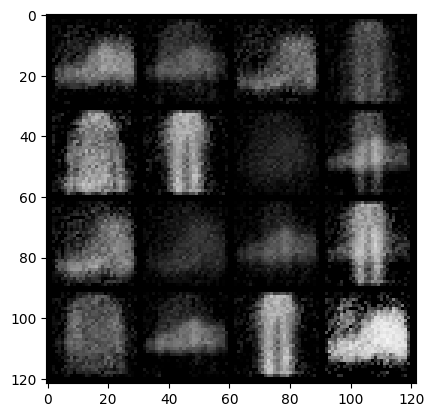

In [ ]:
noise = torch.randn(16,100).to(device)
fake = G(noise).cpu().detach()

grid = torchvision.utils.make_grid(fake, nrow=4)
plt.imshow(grid.permute(1,2,0))
plt.show()

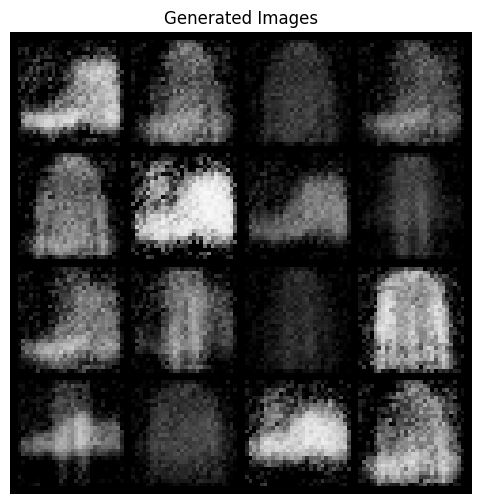

In [ ]:
noise = torch.randn(16,100).to(device)
fake_images = G(noise).cpu().detach()

grid = torchvision.utils.make_grid(fake_images, nrow=4)

plt.figure(figsize=(6,6))
plt.imshow(grid.permute(1,2,0))
plt.title("Generated Images")
plt.axis('off')
plt.show()

In [ ]:
import torchvision.utils as vutils

vutils.save_image(fake_images, "gan_output.png", nrow=4)
print("Saved as gan_output.png")

Saved as gan_output.png


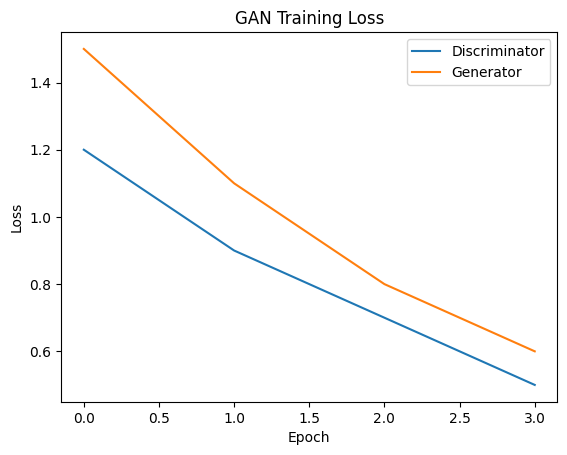

In [ ]:
# If you stored losses, use them
# Example:
D_loss = [1.2, 0.9, 0.7, 0.5]
G_loss = [1.5, 1.1, 0.8, 0.6]

plt.figure()
plt.plot(D_loss, label='Discriminator')
plt.plot(G_loss, label='Generator')

plt.legend()
plt.title("GAN Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()